In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

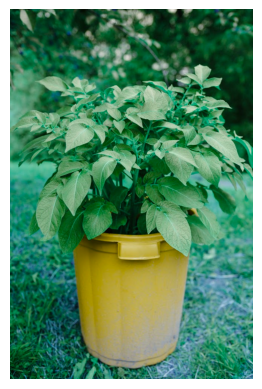

In [4]:
def extract_leaf(image_path):
    image = cv2.imread(image_path)
    blurred = cv2.GaussianBlur(image, (5, 5), 0)

    hsv = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)
    lower_green = np.array([25, 40, 40])
    upper_green = np.array([85, 255, 255])

    mask = cv2.inRange(hsv, lower_green, upper_green)

    # Чистим маску
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    # Находим контуры
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None

    # Самый большой контур — предполагаемый лист
    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)
    leaf = image[y:y+h, x:x+w]

    return leaf

img_array = extract_leaf('C:/PythonProjects/plant_disease_class/new_plant/test/test/container_potatoes.png')

plt.imshow(img_array)
plt.axis('off')
plt.show()